# TEBOL with three classes

The same four phases on cucumber, zucchini and hotpot, to show the
decomposition is not a property of there being two classes.

Phases A, B and D call the Qwen server; phase C uses the cached embeddings.

In [1]:
import os, sys
from pathlib import Path
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

for line in (ROOT / ".env").read_text().splitlines():
    if line.strip() and not line.startswith("#") and "=" in line:
        k, _, v = line.partition("=")
        os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

CLASSES, N_WORDS = ["cucumber", "zucchini", "hotpot"], 5
print(f"repo root: {ROOT.name}/")

repo root: TEBOL/


## Pick an image, held out of training below.

n07718472_1006 | cucumber


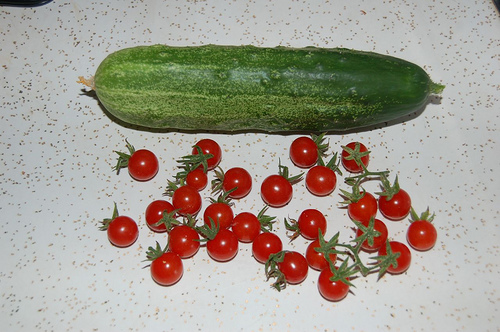

In [2]:
from PIL import Image

img_path = sorted((ROOT / "data" / "raw" / "cucumber_zucchini" / "cucumber").glob("*.JPEG"))[4]        # index 4 has an ImageNet box
stem, true_class = img_path.stem, img_path.parent.name
print(stem, "|", true_class)
Image.open(img_path)

## Phase A — Captioning

The model is told only the word count.

In [3]:
from tebol.captioners import get_captioner, build_prompt

cap = get_captioner("local")
print(build_prompt(N_WORDS))

caption = cap.caption(img_path, n_words=N_WORDS, temperature=1.0, seed=0).text
caption

Describe this image in 5 words.


'Fresh cucumber and cherry tomatoes.'

## Phase B — Embedding

Each word becomes a vector; the caption is their mean, $\tilde A = \frac1n\sum_i \mathbf e_i$.

In [4]:
from tebol.text import tokenize
from tebol.embedders import get_embedder

words = tokenize(caption, split_hyphens=False)
out = get_embedder("local").embed(words)
assert out.vectors is not None, out.error
E = np.asarray(out.vectors, dtype=np.float32)
A = E.mean(axis=0)

print(words)
print("word vectors", E.shape, " caption vector", A.shape)

['fresh', 'cucumber', 'and', 'cherry', 'tomatoes']
word vectors (5, 2560)  caption vector (2560,)


## Phase C — Concept discovery

One-vs-rest, so each class gets its own weight vector and each word gets one
score per class.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from tebol.arms import caption_means, load_classes

data = load_classes(ROOT, CLASSES, "caption", N_WORDS)
X, y = caption_means(data), data.cls
keep = data.stem != stem                       # hold this image out
clf = OneVsRestClassifier(
    LogisticRegression(max_iter=2000, class_weight="balanced")).fit(X[keep], y[keep])

classes = list(clf.classes_)
beta = np.vstack([e.coef_.ravel() for e in clf.estimators_])      # [3, 2560]
bias = np.array([float(e.intercept_[0]) for e in clf.estimators_])
Z = E @ beta.T                                                     # [n_words, 3]

print(f"{'word':<14}" + "".join(f"{c:>12}" for c in classes))
for w, row in zip(words, Z):
    print(f"{w:<14}" + "".join(f"{v:>12.3f}" for v in row))

word              cucumber      hotpot    zucchini
fresh                1.993      -3.683      -1.073
cucumber            14.497      -5.964      -8.392
and                 -2.292       4.151      -0.988
cherry               1.464      -1.129      -0.629
tomatoes             1.077      -1.476      -1.587


The logit still splits exactly, now once per class:

$$\text{logit}_k(S) = b_k + \frac1n\sum_i \underbrace{(\boldsymbol\beta_k\cdot\mathbf e_i)}_{z_{i,k}}$$

In [6]:
rebuilt = bias + Z.mean(axis=0)
model = clf.decision_function([A])[0]

print(f"{'':<14}" + "".join(f"{c:>12}" for c in classes))
print(f"{'mean(z)':<14}" + "".join(f"{v:>12.3f}" for v in Z.mean(axis=0)))
print(f"{'+ bias':<14}" + "".join(f"{v:>12.3f}" for v in bias))
print(f"{'= logit':<14}" + "".join(f"{v:>12.3f}" for v in rebuilt))
print(f"{'model logit':<14}" + "".join(f"{v:>12.3f}" for v in model))
print(f"\nlargest error {np.abs(rebuilt - model).max():.2e}")
print(f"predicted {classes[int(rebuilt.argmax())]}   true {true_class}")

                  cucumber      hotpot    zucchini
mean(z)              3.348      -1.620      -2.534
+ bias               1.235      -2.088      -0.728
= logit              4.583      -3.708      -3.262
model logit          4.583      -3.708      -3.262

largest error 5.36e-07
predicted cucumber   true cucumber


## Phase D — Localization

The top three words for the predicted class go back to the vision model.

In [7]:
from tebol import bbox as B

k = int(rebuilt.argmax())
top3 = [w for w, _ in sorted(zip(words, Z[:, k]), key=lambda t: -t[1])[:3]]
prompt = B.build_prompt(top3)
print(prompt)

reply = cap.ask(img_path, prompt, max_tokens=512, temperature=0.0, seed=0).text
print(repr(reply))

Provide bounding box coordinates for the object from (cucumber, fresh, cherry). Format: x_min, y_min, x_max, y_max with integers only.


'154, 135, 888, 405  \n198, 405, 875, 900'


Qwen answers on a 0–1000 grid, so the box is rescaled to pixels.

In [8]:
boxes, err = B.parse_boxes(reply)
W, H = Image.open(img_path).size
px = [B.rescale(b["box"], W, H)[0] for b in boxes]

print("parse:", err or "ok")
for b, p in zip(boxes, px):
    print(f"  {str(b['label']):<12}{str(b['box']):<26} -> {p}")

parse: ok
  None        [154, 135, 888, 405]       -> [77, 45, 444, 134]
  None        [198, 405, 875, 900]       -> [99, 134, 438, 299]


Red is TEBOL's box, green is ImageNet's.

TEBOL (red, 'cucumber') [77, 45, 444, 134]
IoU 0.992


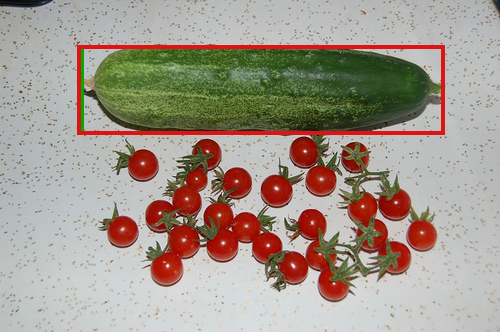

In [9]:
from PIL import ImageDraw

xml = ROOT / "data" / "annotations" / "cucumber_zucchini" / true_class / f"{stem}.xml"
truth = B.truth_boxes(xml)[0] if xml.exists() else []

im = Image.open(img_path).convert("RGB")
d = ImageDraw.Draw(im)
wide = max(4, min(im.size) // 90)
for t in truth:
    d.rectangle(t, outline=(0, 170, 0), width=wide)
d.rectangle(px[0], outline=(220, 20, 20), width=wide)

print(f"TEBOL (red, '{top3[0]}') {px[0]}")
if truth:
    print(f"IoU {B.best_iou(px[0], truth):.3f}")
im